<p align="center">
    <span style="color:chocolate; font-size:2.5em; font-weight:bold;">
        eFleetPlan - Optimal infrastructure and fleet operation of electric LCV
    </span>
</p>

<p align="center">
    <span style="font-size:1.5em; font-weight:bold;">
        Carolina Gil Ribeiro, Jagruti Thakur
    </span>
</p>

## 0. Importing dependencies

In [1]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory 
import pandas as pd
import numpy as np
import xlsxwriter as xl
import matplotlib.pyplot as plt
import os
from glob import glob
from matplotlib import rcParams
from datetime import datetime
from pyomo.opt.results import SolverStatus
import datetime as dt
import math
from typing import Literal
import time
from matplotlib.ticker import MaxNLocator

import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from optimalcharge_modules._1_schedule.schedule_generator_1 import ScheduleGenerator
from optimalcharge_modules._1_schedule.schedule_configure import scheduletype, vehicletype, companytype
from optimalcharge_modules._1_schedule.schedule_generator_2 import generate_schedules
from optimalcharge_modules._1_schedule.generate_graphs import generate_graphs



from optimalcharge_modules._2_optimisation.optimisation import assign, optimisation, save_results, calculate_days
from optimalcharge_modules._2_optimisation.optimisation_graphs import graph_vehicles, plot_summary_table, process_folder, graph_number_of_chargers_by_schedules, graph_chargingpower, graph_powerbytype

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
notebook_dir = os.getcwd()

# <span style="color:chocolate;">1. SCHEDULE GENERATOR MODULE</span>

<span style="color:green">

## 1.1 Schedyle generator configurations
</span>

In this module, the only required input file is the Energy Consumption Factor.
This factor is used to adjust energy consumption values based on changes in temperature, accounting for environmental and operational variations.

The example uses hourly temperature data from the "Stockholm-Observatorielunden A" measurement station, provided by the Swedish Meteorological and Hydrological Institute (SMHI).

In [18]:
# environment arguments - adjust settings if necessary
env_config = {"original_seed": 42,  # Seed for RNG - can be set to None so always random (not recommended)
                    
              # settings below if you want to generate new schedules
              "gen_start_date": "2023-01-01 00:00:00",  # New schedule, start date
              "gen_end_date": "2023-12-31 23:00:00",  # New schedule, end date
              "freq": "h",  # 'h' means hourly frequency. .
              
              "EVs": 150, # Number of electric vehicles in the fleet
                            
              # path to the CSV file with energy consumption factor (the example if for Stockholm 2023)
              # This value can be adjusted to other locations with hourly temperature data
              "consumption_factor_file" : os.path.join(notebook_dir, "data", "Input", "Energy_consumption_factor_2023.csv")  
                                         
              }

<span style="color:green">

## 1.2. Fleet parameters configurations

</span>


It is possible to generate diferent types of schedules, adjusting different parameters.
Schedule configuration includes: Type of schedule (a or b), Type of vehicle (Catefory 1 - Renault and Category 2 - Toyota) and Company type.

New fleet parameters can be defined/created in the file "schedule_configure.py".

#### Type of Schedule
Schedules are categorised into two types: Type A, which consists of a continuous schedule, and Type B, which includes breaks. Various parameters are established to facilitate realistic modelling of daily logistics schedules, including mean departure and return times, standard deviations, and allowable time ranges.
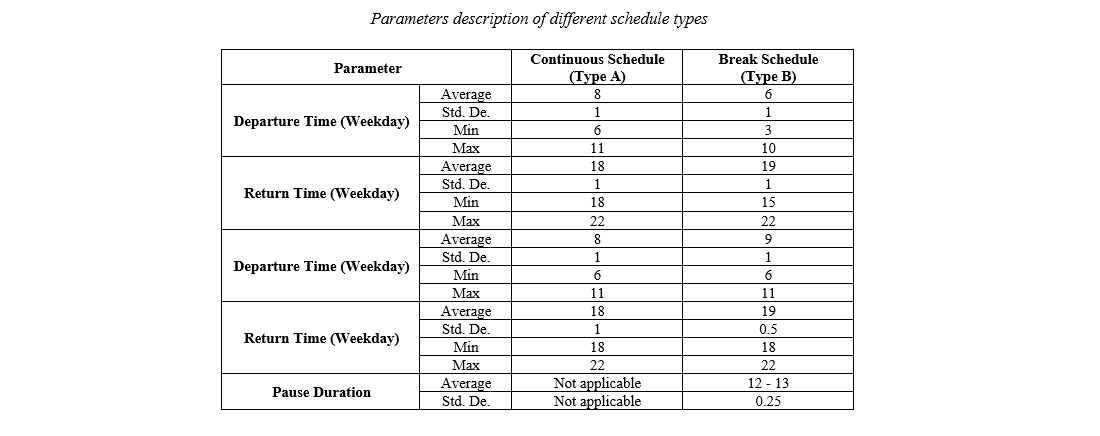

#### Type of vehicle: n_Renault and n_toyota

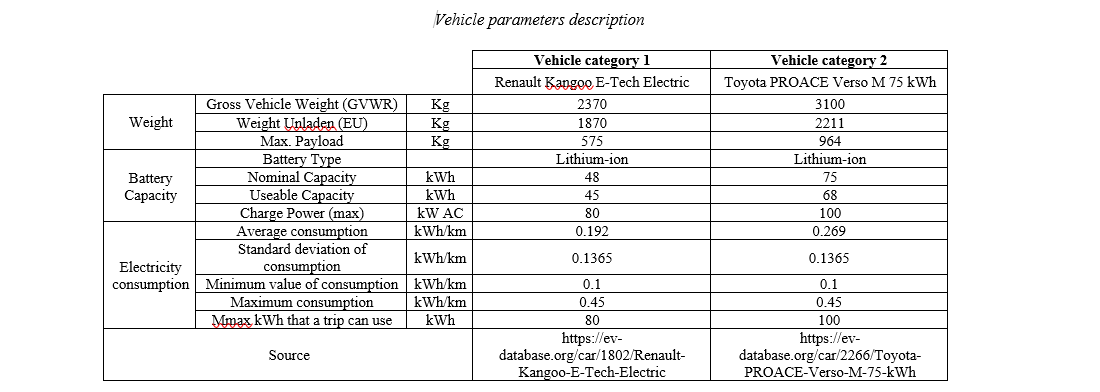

#### Company type
The values related to company type are defined based on the findings of a survey on light goods vehicles in Sweden conducted by Transport Analysis in 2022. 

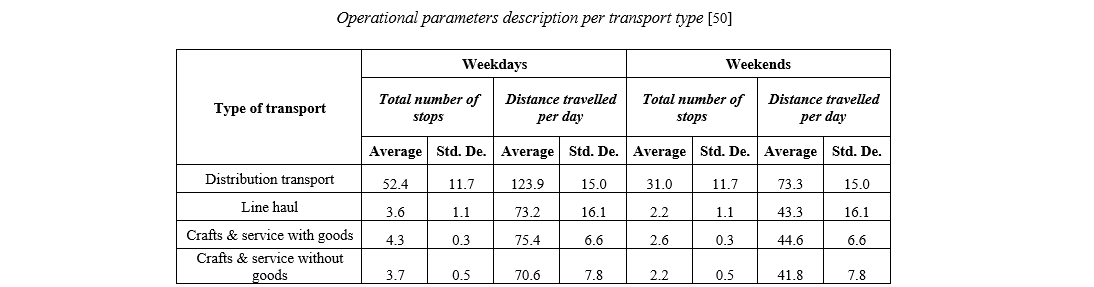

notes: Type of transport is defined as the primary use of the LCV and are described as follows: distribution transport for goods or commodities transports with several stops for loading and unloading along the way; Line haul goods or commodities transports, directly from one place to another;  Crafts and services with goods transports include trips for craft or service vehicle that include goods or merchandise to be used or installed in the work; and crafts and services without goods correspond to craft or service trips without goods or merchandise.

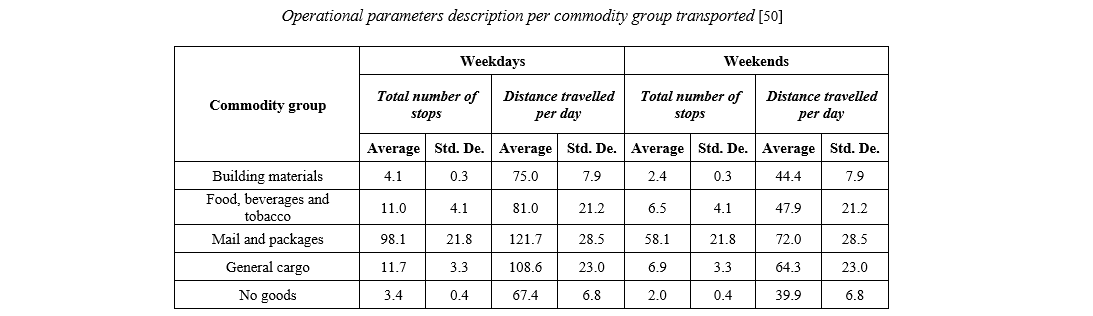

notes: Commodity groups were formulated in Light Goods Vehicles 2022 survey to capture the type of goods commonly transported identified by the vehicles.

### Schedule generator configurations

In [ ]:
# Schedule arguments - adjust settings if necessary
sch_config = {"Vehicles number": 150,  # Number of vehicles in the fleet
              
              "Type of schedule": {"type a": 150, "type b": 0},  # Type A, which consists of a continuous schedule, and Type B, which includes breaks, going to the distribution terminal durind the day. 
              
              "Type of vehicle": {"Renault": 100, "Toyota": 50},  # Renault or Toyota
              
              "Company type": companytype.Distribution, # Types of company: Distribution, LineHaul, CraftServWithGoods, CraftServWithoutGoods, Food, Mail, Building, Highdistance, Generalcargo, Nogoods
              
              #"Company type":companytype.Costum,  # Custom company type, if you want to generate a custom schedule with your own distance and stops parameters
              "Costum Distance": {"average weekday":120,  # Average distance travelled on a weekday in km
                                "average weekend": 70,  # Average distance travelled on a weekend in km 
                                "standard deviation weekday": 15,  # Standard deviation of distance travelled on a weekday in km
                                "standard deviation weekend": 15,  # Standard deviation of distance travelled on a weekend in
                                "min distance": 30,  # Minimum distance travelled in km
                                "max distance": 300,  # Maximum distance travelled in km  
                                "min distance per hour": 1,  # Minimum distance travelled per hour in km
                                "max distance per hour": 50,  # Maximum distance travelled per hour in km
                                "average stops": 30,  # Average number of stops per day
                                "standard deviation stops": 10  # Standard deviation of number of stops per                  
                                },
              
              "Schedule name": 'Schedule_1'  # Name of the schedule:
                }

## 1.3. Schedule Generation

Define the vehicle fleet and type of schedule to generate in the following cell. It is possible to duplicate the cell and generate schedules for differents vehicle fleets.

In [20]:
schedule_1 = generate_schedules(env_config, sch_config)

### Save parameters files in CVS

In [21]:
# Save individual files for each parameter for both schedules
parameters = ['Distance_km', 'Consumption_kWh', 'Consumption_km', 'Location', 'ChargingStation', 'PowerRating_kW', 'ScheduleType', 'consumption_factor']

for schedule, schedule_name in zip([schedule_1], ['1']):
    for parameter in parameters:
        # Pivot the table for the current parameter
        pivoted_schedule = schedule.pivot_table(
            index='date', 
            columns='VehicleID', 
            values=parameter, 
            aggfunc='first'
        )

        # Flatten the multi-index columns
        pivoted_schedule.columns = [f'{parameter}_Vehicle_{vehicle}' for vehicle in pivoted_schedule.columns]
        
        # Reset the index to bring 'date' as a column
        pivoted_schedule.reset_index(inplace=True)
        
        # Folder name
        folder_name = f'Schedule_{schedule_name}'

        # Create and check on the folder Output in data folder in the project root
        output_folder = os.path.join(notebook_dir, '..', 'data', 'Output', folder_name)
        if not os.path.exists(output_folder):
            os.makedirs(output_folder)
        
        # Save each parameter to a separate CSV file in the output_folder
        file_name = os.path.join(output_folder, f'{schedule_name}_all_vehicles_{parameter}.csv')
        pivoted_schedule.to_csv(file_name, index=False)

In [22]:
print(schedule.head())

                 date  Distance_km  Consumption_kWh  Consumption_km Location  \
0 2023-01-01 00:00:00          0.0              0.0             0.0        1   
1 2023-01-01 01:00:00          0.0              0.0             0.0        1   
2 2023-01-01 02:00:00          0.0              0.0             0.0        1   
3 2023-01-01 03:00:00          0.0              0.0             0.0        1   
4 2023-01-01 04:00:00          0.0              0.0             0.0        1   

  ChargingStation ID  PowerRating_kW  consumption_factor VehicleID  \
0               1  0              80                 1.0         0   
1               1  0              80                 1.0         0   
2               1  0              80                 1.0         0   
3               1  0              80                 1.0         0   
4               1  0              80                 1.0         0   

  ScheduleType VehicleType   CompanyType  
0        Typea     Renault  Distribution  
1        Typ

## 1.4. Schedules post-processing and visualisation

### Graphs generation per schedule
If you have more than one type of fleet, just need to add the folder name in the next cell.

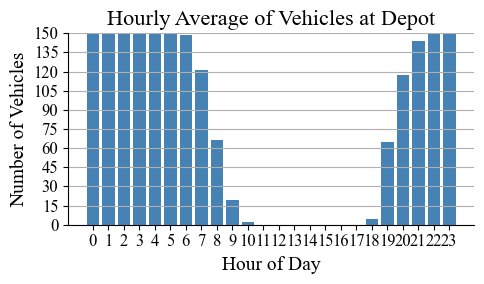

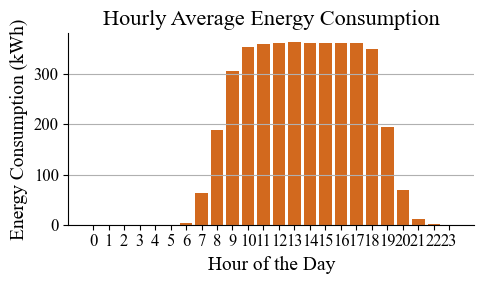

In [23]:
folders = ['Schedule_1']

for folder in folders:
    schedule_name = folder.split("_")[1]
    output_folder = os.path.join(notebook_dir, '..', 'data', 'Output', folder)
    distance_file_path = os.path.join(output_folder, f'{schedule_name}_all_vehicles_Distance_km.csv')
    charging_file_path = os.path.join(output_folder, f'{schedule_name}_all_vehicles_ChargingStation.csv')
    consumption_file_path = os.path.join(output_folder, f'{schedule_name}_all_vehicles_Consumption_kWh.csv')

    
    generate_graphs(distance_file_path, charging_file_path, consumption_file_path, folder, output_folder)


# <span style="color:chocolate;">2. Charging Infrastructure Optimisation Module</span>

<span style="color:green">

## 2.1 Optimisation parameters configurations

</span>

In [24]:
# environment optimisation arguments - adjust settings if necessary
opt_config = {# settings for the optimisation function              
              "opt_start_date": "2023-01-01 00:00:00",  # New schedule, start date
              "opt_end_date": "2023-12-31 23:00:00",  # New schedule, end date
              "freq": "h",  # 'h' means hourly frequency. .
              
              "EVs": 150, # Number of electric vehicles in the fleet
              
              #Input and output folders
              "output_folder" : os.path.join(project_root, 'data', 'Output', 'Schedule_1'),
              "input_folder" : os.path.join(project_root, 'data', 'Input'),
              
              # CSV file with electricity prices (the example is for SE3 in Stockholm, Sweden)
              "electricity_price_grid" : pd.read_csv(os.path.join(project_root, 'data', 'Input', 'SE3_el_prices_2023_modified.csv')),
              
              
              # Load the data for the vehicles created in the schedule generator module
              ## Energy consumption file
              "En_consumption" : pd.read_csv(os.path.join(project_root, 'data', 'Output', 'Schedule_1', '1_all_vehicles_consumption_km.csv')),
              ## Distance travel per vehicles and per hour file
              "Ev_distance" : pd.read_csv(os.path.join(project_root, 'data', 'Output', 'Schedule_1', '1_all_vehicles_Distance_km.csv')),
              ## Vehicles availability to charge at de distribution terminal              
              "Ev_availability_file" : pd.read_csv(os.path.join(project_root, 'data', 'Output', 'Schedule_1', '1_all_vehicles_ChargingStation.csv')),
              ## Vehicle battery power - important when the fleet has more than one type of vehicle                                         
              "Battery_Limitation" : pd.read_csv(os.path.join(project_root, 'data', 'Output', 'Schedule_1', '1_all_vehicles_PowerRating_kW.csv')) 
                                         
              }

## 2.2. Cost Configuration

In the cost configurations above, it is possible to change the values related to cost of infrastructure, energy subscription rates and route charging rates.

In [25]:
cost_config = {"Infrastructure_life": 20, #lifetime or ownership time of the charging infrastucture
               "Infrastructure_cost": {'s': 32000 + 29000, # Slow charger cost
                                       50: 294000 + 472000, # Fast charger 50 kw cost
                                       150: 778000 + 644000, # Fast charger 150 kw cost
                                       350: 1451000 + 1202000}, # Fast charger 350 kw cost
               "Charger_Power" : {'s': 7.4, 'Route': 150, 50: 50, 150: 150, 350: 350},  # Charging power of each type of charger
               "maintenance_cost" : {'s': 5000, 50: 40000, 150: 120000, 350: 240000}, # Maintenance cost per type of charger
               
               "Infrastructure_subscription" : 50,  # kr/day,
               "Price_FixedrateDT" : 0.0331,
               "Demand_rate" : 1352,
               "Price_FixedrateRoute" : 8.90
               }

## 2.3 Run Optimisation

In [26]:
# Call the optimisation function
m, Price, EV_availability, Distance_km = optimisation(opt_config, cost_config)

Number of days: 365
      255.12 seconds required to write file
      255.12 seconds required for presolve
Set parameter Username
Set parameter LicenseID to value 2646498
Academic license - for non-commercial use only - expires 2026-04-02
Read LP format model from file C:\Users\mcgr2\AppData\Local\Temp\tmp0sxsu4kz.pyomo.lp
Reading time = 32.87 seconds
x1: 19762560 rows, 21024157 columns, 53366601 nonzeros
Set parameter MIPGap to value 0.25
Set parameter ScaleFlag to value 2
Set parameter LogFile to value "gurobi_log_3.txt"
Set parameter Method to value -1
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: AMD Ryzen Threadripper PRO 7965WX 24-Cores, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 24 physical cores, 48 logical processors, using up to 24 threads

Non-default parameters:
MIPGap  0.25
ScaleFlag  2

Optimize a model with 19762560 rows, 21024157 columns and 53366601 nonzeros
Model fingerprint: 0x3eba4647
Variable types: 14454157

### Saving results

In [27]:
# Ensure the output directory exists before saving results
results_folder = os.path.join(project_root, 'data', 'Output', 'Schedule_1', 'Results')
os.makedirs(results_folder, exist_ok=True)

csv_file_pathA = os.path.join(results_folder, '1_Main_variables_results.csv')
csv_file_pathB = os.path.join(results_folder, '1_results_summary.csv')
csv_file_pathC = os.path.join(results_folder, '1_results_per_EV.csv')
csv_file_pathD = os.path.join(results_folder, '1_results_per_EV_descriptive.csv')

save_results(m, Price, EV_availability, Distance_km, csv_file_pathA, csv_file_pathB, csv_file_pathC, csv_file_pathD, cost_config)

✅ Results saved successfully!


## 2.4. Post-processing and visualisation

C:\Carolina\Software_paper\EFleet_env\EFleetO-main\EFleetO-main\optimalcharge_modules\_2_optimisation\optimisation_graphs.py:57: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table_df = df.pivot_table(index='Category', columns='Description', values='Value', sort=False)


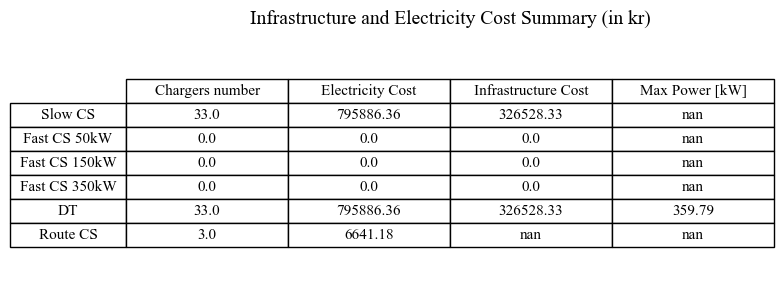

In [28]:
# Set the path to your folder
file_pattern_mean = os.path.join(project_root, 'data', 'Output', 'Schedule_1', 'Results', '*_results_summary.csv')

# Use glob to find the actual file
matched_files = glob(file_pattern_mean)
if not matched_files:
    raise FileNotFoundError(f"No file matches the pattern: {file_pattern_mean}")
file_path = matched_files[0]


plot_summary_table(file_path)

### Create maximum and average files

In [29]:
# Set the path to your folder
folder_path = os.path.join(project_root, 'data', 'Output', 'Schedule_1', 'Results')

# Find all files with the pattern *_hourly_averages.csv
filename_pattern = os.path.join(folder_path, '*_Main_variables_results.csv')

process_folder(folder_path, filename_pattern)

Processed 1_Main_variables_results.csv in c:\Carolina\Software_paper\EFleet_env\EFleetO-main\EFleetO-main\data\Output\Schedule_1\Results.


1


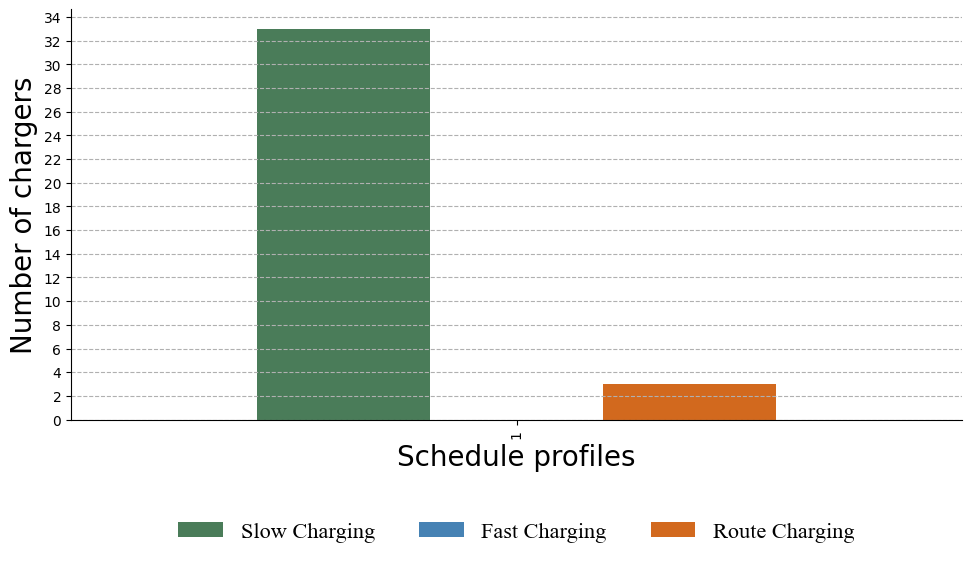

In [2]:
# Set the path to your folder
folder_path = os.path.join(project_root, 'data', 'Output', 'Schedule_1', 'Results')
file_pattern_max = os.path.join(project_root, 'data', 'Output', 'Schedule_1', 'Results', '*_max_variable_per_hour.csv')
files_hourly_max = glob(file_pattern_max)

graph_number_of_chargers_by_schedules(folder_path, files_hourly_max)

### Graph 2 - Average charging power and average price of electricity

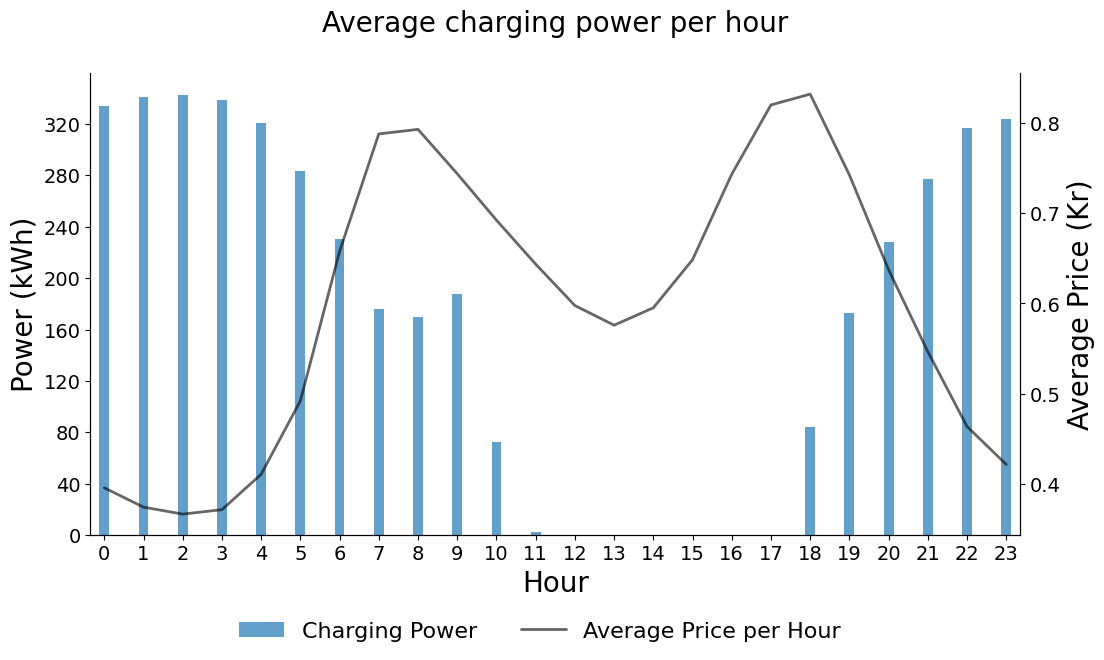

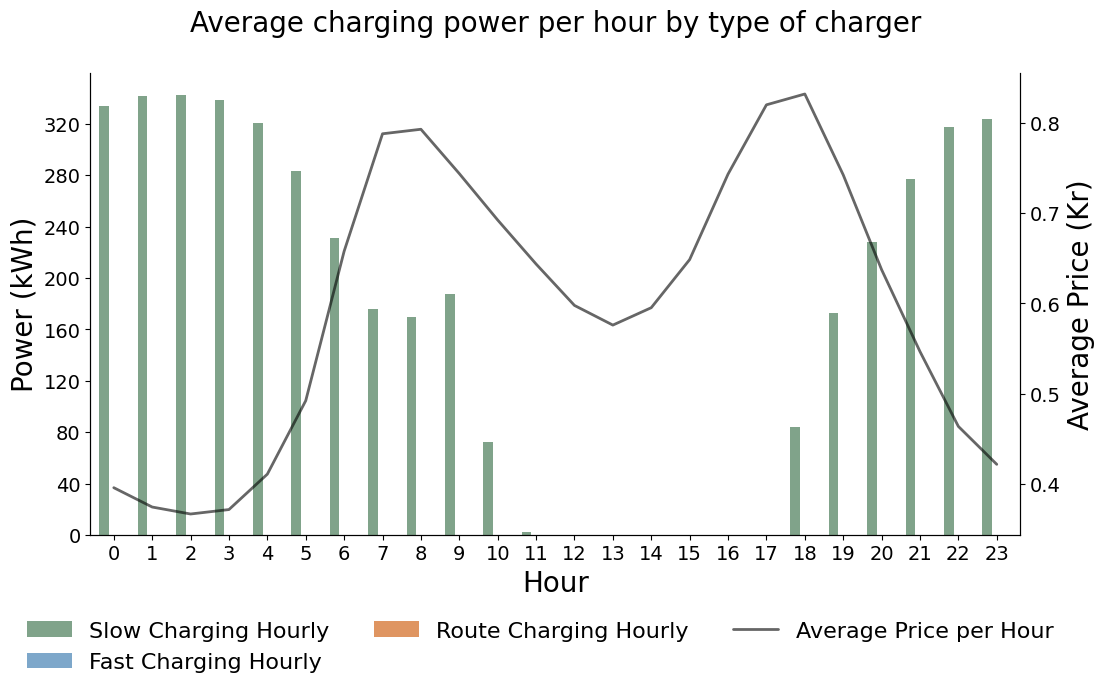

In [2]:
# Set the path to your folder
file_pattern_mean = os.path.join(project_root, 'data', 'Output', 'Schedule_1', 'Results', '*_avg_variable_per_hour.csv')

# Use glob to find the actual file
matched_files = glob(file_pattern_mean)
if not matched_files:
    raise FileNotFoundError(f"No file matches the pattern: {file_pattern_mean}")
file_path = matched_files[0]
folder_path = os.path.join(project_root, 'data', 'Output', 'Schedule_1', 'Results')

    
graph_chargingpower (file_path, folder_path)
graph_powerbytype (file_path, folder_path)

### Graph 3 - Charging, discharging power and SOC

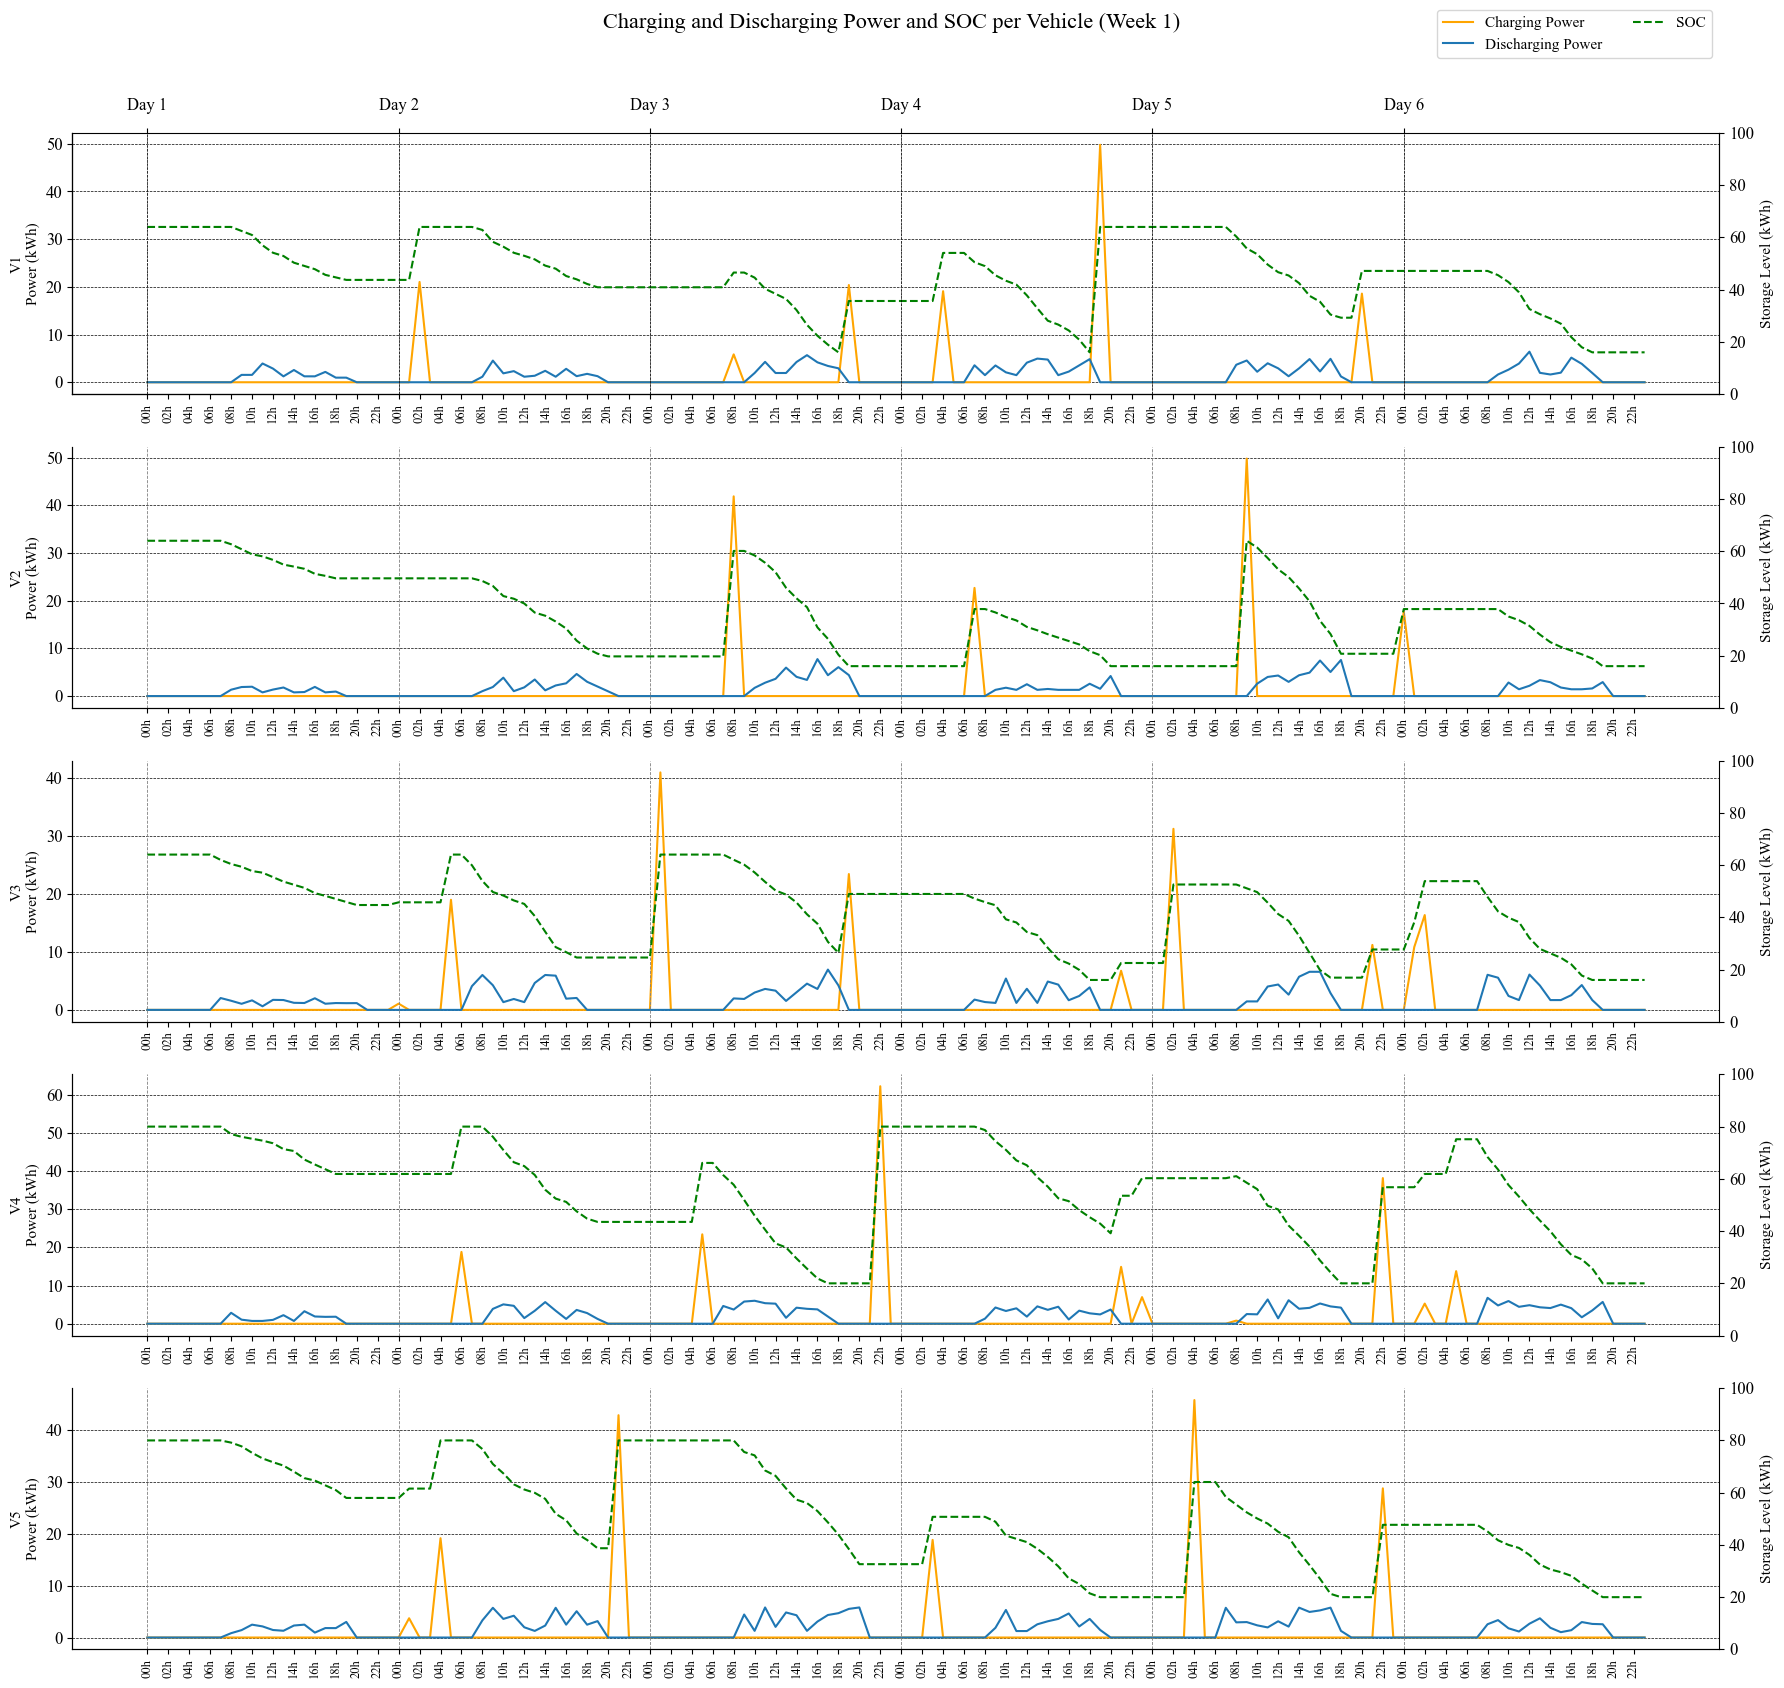

In [32]:
# Set the path to your folder
file_pattern_pervehicle = os.path.join(project_root, 'data', 'Output', 'Schedule_1', 'Results', '*_results_per_EV_descriptive.csv')

# Use glob to find the actual file
matched_files = glob(file_pattern_pervehicle)
if not matched_files:
    raise FileNotFoundError(f"No file matches the pattern: {file_pattern_pervehicle}")
file_path = matched_files[0]


# Set the number of vehicles for the graph
n_vehicles = 5
# Set the number of days for the graph
n_days = 6


graph_vehicles(file_path,n_days, n_vehicles)